# CNN-Model

The purpose of this assignment was to create neural networks capable of a simple image classification task. The report for this assignment is included in the three jupyter notebooks and are intended to be read in the order: "Kuvantunnistus_CNN", "Kuvantunnistus_EfficientNet", "Kuvantunnistus_Finetunded". This ensures the integrity of the reading experience.

The dataset for this assignment consists of 300 images of hands with varying numbers of extended fingers, captured across different individuals, lighting conditions, and orientations. To prevent bias, the dataset is balanced, containing an equal number of images for each class. The classification task requires the models to determine the number of extended fingers in each image.

In this file the first model: A custom convolutional neural network is created, trained and analyzed.

## Data preparation

In [2]:
import os
import glob
import keras

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers

In [3]:
base_dir = ''

train_dir = os.path.join(base_dir, 'Train')
val_dir = os.path.join(base_dir, 'Test')
test_dir = os.path.join(base_dir, 'Validation')

one_dir = os.path.join(train_dir, '1')
two_dir = os.path.join(train_dir, '2')
three_dir = os.path.join(train_dir, '3')
four_dir = os.path.join(train_dir, '4')
five_dir = os.path.join(train_dir, '5')

one_imgs = os.listdir(one_dir)
two_imgs = os.listdir(two_dir)
three_imgs = os.listdir(three_dir)
four_imgs = os.listdir(four_dir)
five_imgs = os.listdir(five_dir)

The image files are organized and five images from each class are shown below.

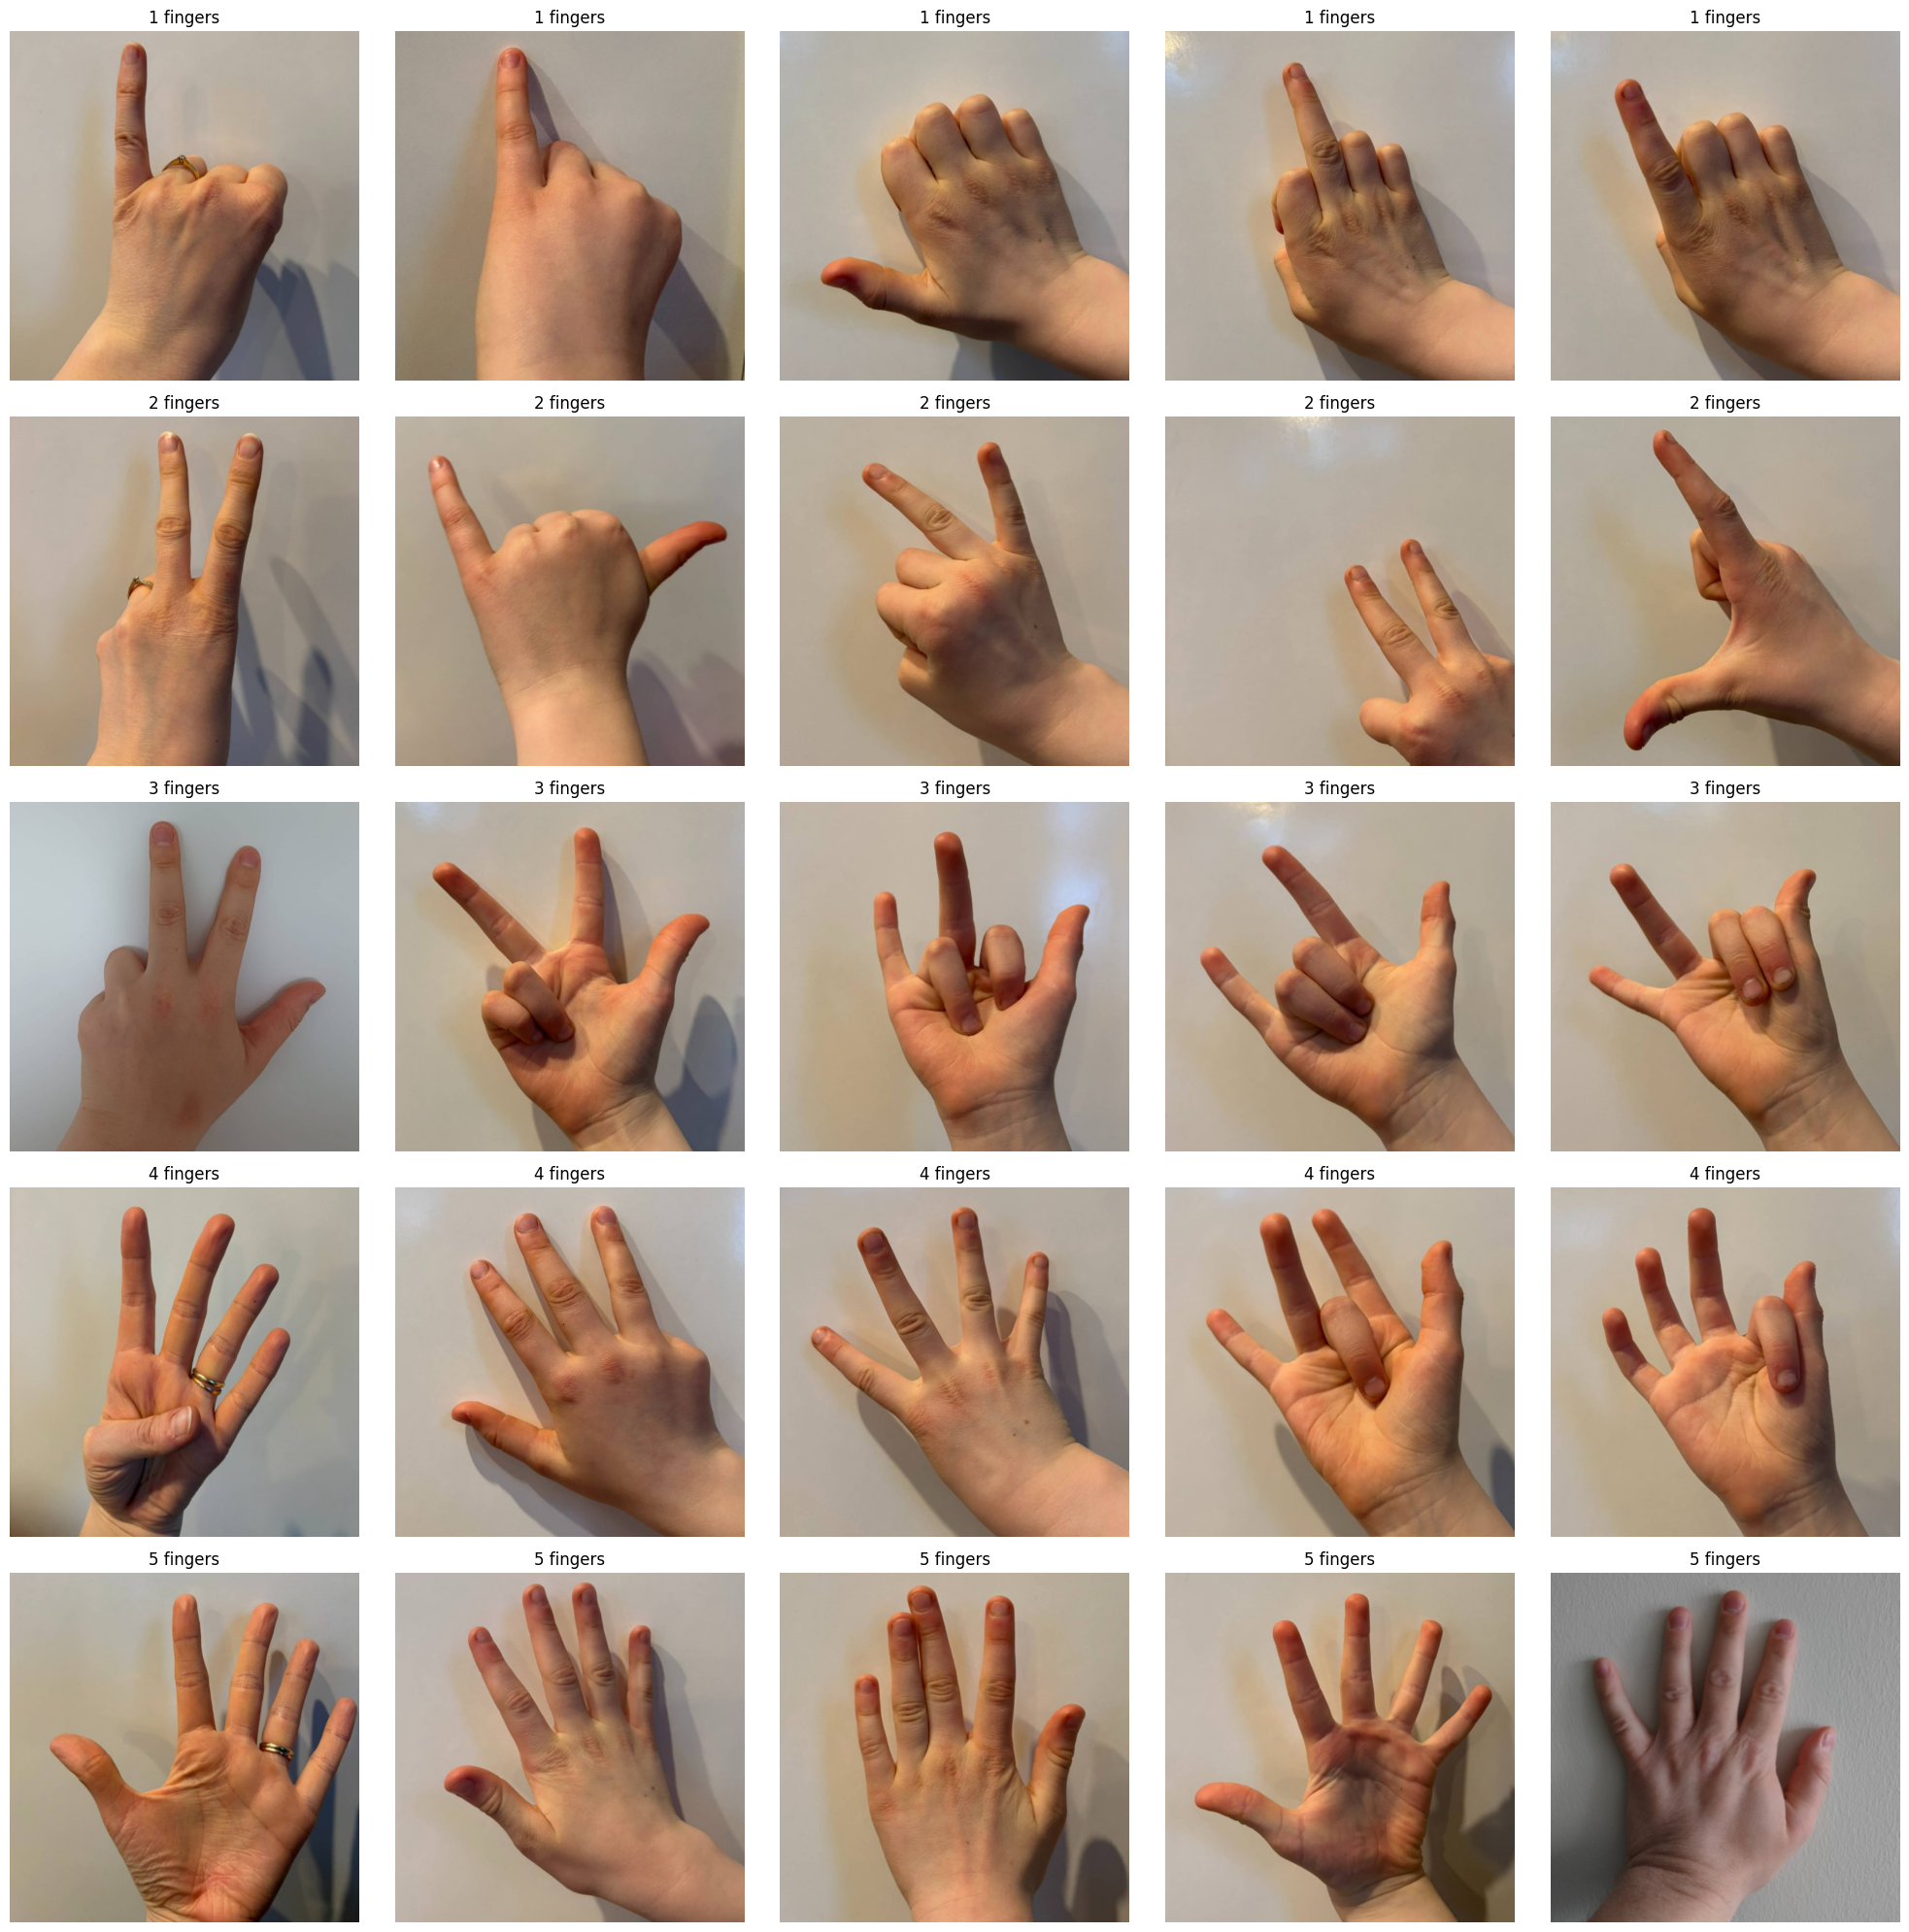

In [4]:
class_dirs = [one_dir, two_dir, three_dir, four_dir, five_dir]
class_imgs = [one_imgs, two_imgs, three_imgs, four_imgs, five_imgs]

plt.figure(figsize=(20, 20))

for row, (img_list, img_dir) in enumerate(zip(class_imgs, class_dirs)):
    for col, img_name in enumerate(img_list[:5]):
        plt.subplot(5, 5, row * 5 + col + 1)
        img = mpimg.imread(os.path.join(img_dir, img_name))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{row+1} fingers")

plt.tight_layout()
plt.show()

In [5]:
BATCH_SIZE = 32
TARGET_SIZE = 128
EPOCHS = 300

Since the dataset is very small, to improve the model's generalization and prevent overfitting, data augmentation techniques are applied to the training set, including random rotations, shifts, zooms, and horizontal flips. The images pixel values are also rescaled to range from 0 to 1, to improve training later.

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

validation_test_datagen = ImageDataGenerator(rescale=1.0/255)

Next the images are loaded and preprocessed using the ImageDataGenerators created above.

In [7]:
train_generator = train_datagen.flow_from_directory(train_dir, 
                                                    target_size=(TARGET_SIZE, TARGET_SIZE), 
                                                    batch_size=BATCH_SIZE, 
                                                    shuffle=True,
                                                    class_mode='categorical')

val_generator = validation_test_datagen.flow_from_directory(val_dir,
                                                       target_size=(TARGET_SIZE, TARGET_SIZE), 
                                                       batch_size=BATCH_SIZE, 
                                                       shuffle=True,
                                                       class_mode='categorical')

test_generator = validation_test_datagen.flow_from_directory(test_dir,
                                                  target_size=(TARGET_SIZE, TARGET_SIZE),
                                                  batch_size=BATCH_SIZE,
                                                  shuffle=False,
                                                  class_mode='categorical',
)

Found 210 images belonging to 5 classes.
Found 45 images belonging to 5 classes.
Found 45 images belonging to 5 classes.


## Model

A simple model is designed to extract spatial features from the images using alternating convolutional and pooling layers. These layers identify patterns in the data, such as edges and other shapes, while reducing the image size. The data is then flattened and passed through fully-connected layers to make the final prediction. Techniques like dropout and regularization are included to prevent overfitting, and the output layer uses the softmax function to provide the probability for the five finger classes.

In [8]:
model = Sequential()
model.add(Input(shape=(TARGET_SIZE, TARGET_SIZE, 3)))

model.add(Conv2D(32, (3,3), activation='relu', padding='same', kernel_initializer='he_normal'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu', padding='same', kernel_initializer='he_normal'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu', padding='same', kernel_initializer='he_normal'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256, (3,3), activation='relu', padding='same', kernel_initializer='he_normal'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)))

model.add(Dense(5, activation='softmax'))

The model is then compiled using the "Adam" optimizer with a learning rate of 0.0001 to ensure stable training. For the loss function, categorical cross-entropy is selected, which is standard one-hot encoded labels. The model tracks accuracy as the evaluation metric to measure performance across the five classes.

In [9]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,486,341 (9.48 MB)

 Trainable params: 2,486,341 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

The model is trained using the training and validation generators. An EarlyStopping callback is implemented to prevent overfitting by monitoring the validation loss. If the validation loss does not improve for 25 consecutive epochs, the training process stops automatically, and the model's weights are restored to the point of the lowest validation loss. Finally, the model is trained for maximum of 300 epochs.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=0,
    callbacks=[early_stop],
)

Epoch 202: early stopping
Restoring model weights from the end of the best epoch: 177.


The optimal model was found at epoch 177, at which point the validation loss reached its lowest point and no better configuration was found in 25 epochs.

## Results

The loss and accuracy values for both the training and validation sets were recorded at each epoch and plotted to allow for visual assessment of the model’s learning behavior.

As shown in both graphs, the validation curve follows the training curve, indicating that the model does not overfit. As can be seen from the accuracy curve the training is somewhat noisy, probably because of the limited and somewhat complex training data. Because of these fluctuations, the ability to restore the best weights is particularly valuable. Without restoring the best weights, stopping the training process at the final epoch could leave the model in a sub-optimal state, as the accuracy may have dropped from its peak during a noisy training phase.

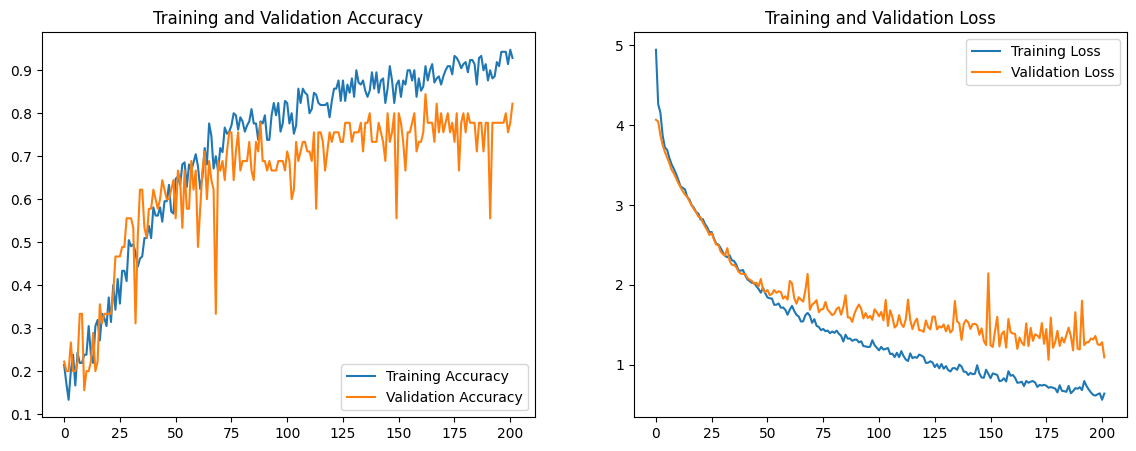

In [11]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

The model reached an accuracy of 80%, which is reasonable considering the limited sample size of 300 images, and the high variation in lighting, orientation, and individuals. Given that there are five different classes, a 80% accuracy indicates that the model is performing significantly better than random guessing (which would be 20%).

In [12]:
test_scores = model.evaluate(test_generator, verbose=2)

print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

2/2 - 0s - 85ms/step - accuracy: 0.8000 - loss: 0.9904
Test loss: 0.9904124736785889
Test accuracy: 0.800000011920929


As we can observe from the confusion matrix below, the diagonal contains the correctly classified instances, while the misclassifications are all at most one finger away from the correct answer. This shows that while the model occasionally misidentifies a finger count, it never makes large errors, such as confusing one finger for five. 

This is a satisfactory result and indicates that a more complex model with more training data could get a near perfect result. The current model successfully establishes a baseline, demonstrating that the network is capable of extracting relevant spatial features and correctly identifying the underlying finger configurations.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


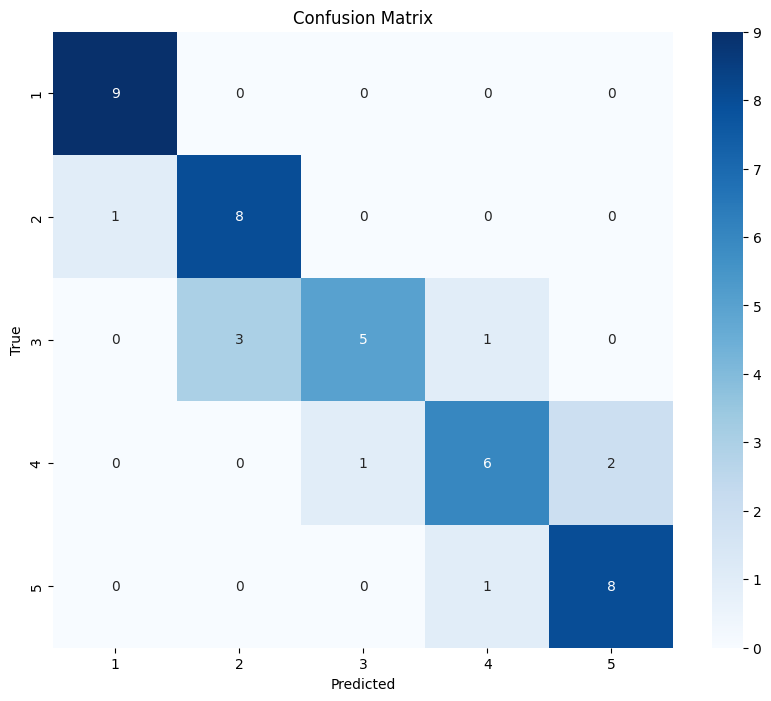

In [13]:
y_true_classes = test_generator.classes

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Below are examples comparing misclassified and correctly classified images, along with the corresponding probabilities assigned by the model.

Total misclassified images: 9 out of 45


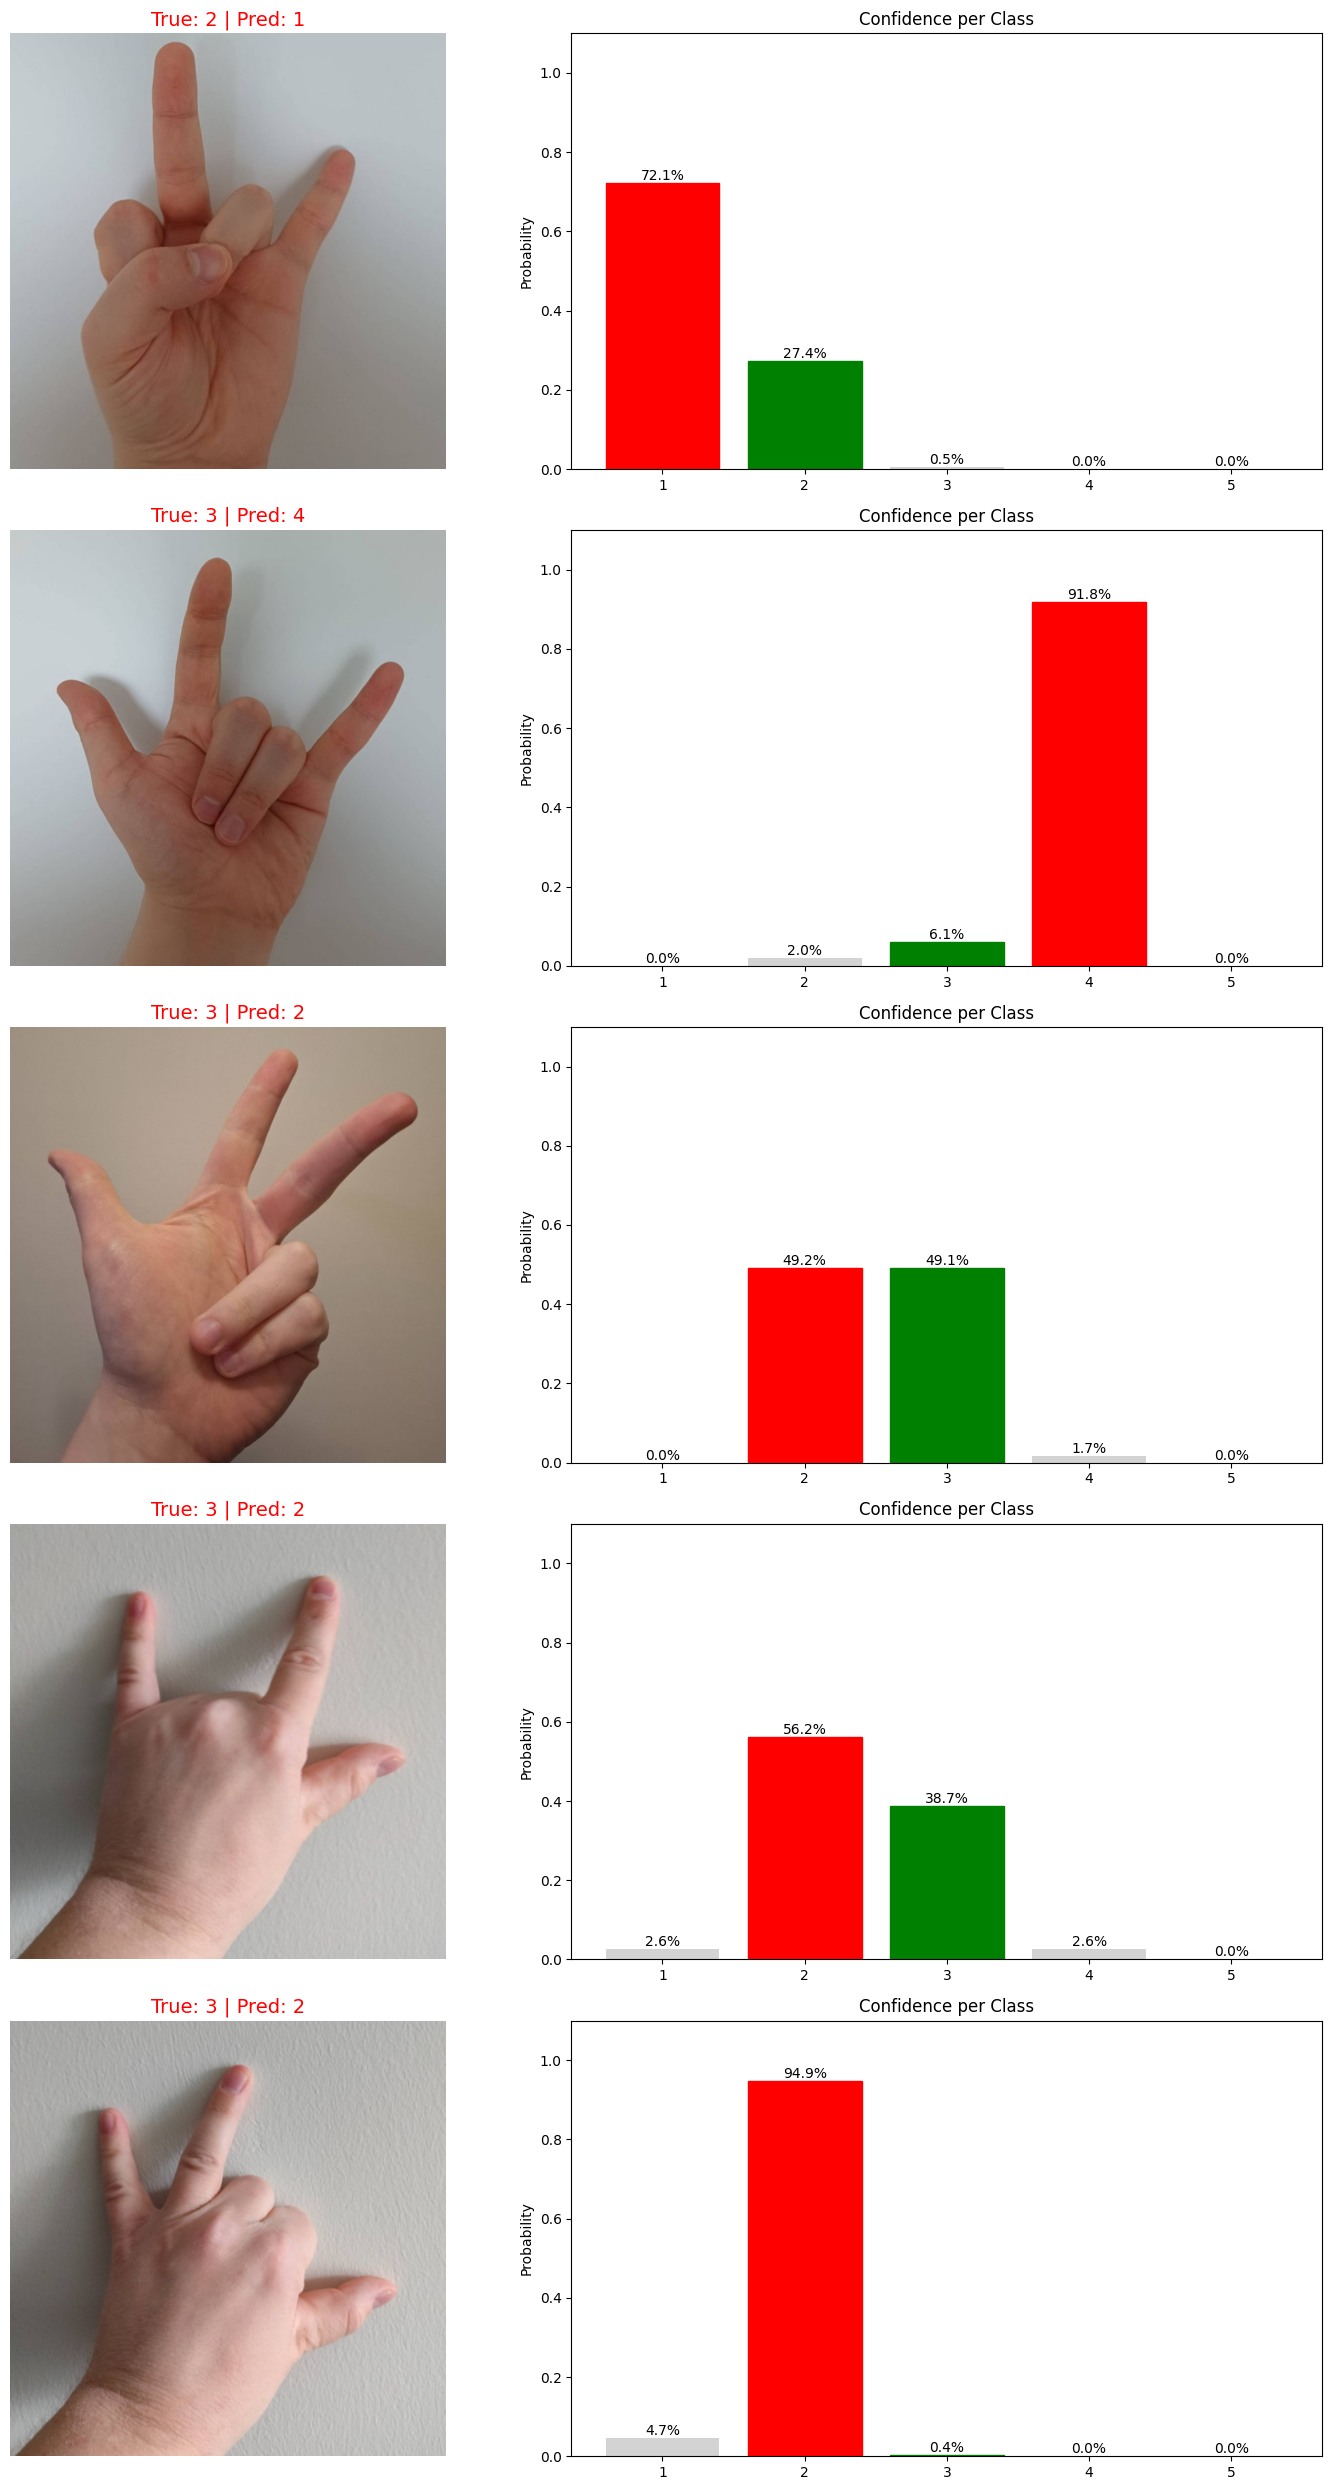

In [14]:
errors = np.where(y_pred_classes != y_true_classes)[0]

num_to_show = 5 
fig, axes = plt.subplots(num_to_show, 2, figsize=(15, 5 * num_to_show))

num_to_show = min(num_to_show, len(errors))

print(f"Total misclassified images: {len(errors)} out of {len(y_true_classes)}")

for i in range(num_to_show):
    idx = errors[i]
    
    img_path = os.path.join(test_generator.directory, test_generator.filenames[idx])
    img = plt.imread(img_path)
    
    axes[i, 0].imshow(img)
    true_label = class_names[y_true_classes[idx]]
    pred_label = class_names[y_pred_classes[idx]]
    axes[i, 0].set_title(f"True: {true_label} | Pred: {pred_label}", color='red', fontsize=14)
    axes[i, 0].axis('off')
    
    probabilities = y_pred[idx]
    
    bars = axes[i, 1].bar(class_names, probabilities, color='lightgray')
    
    true_idx = y_true_classes[idx]
    pred_idx = y_pred_classes[idx]
    
    bars[true_idx].set_color('green')
    bars[pred_idx].set_color('red')
    
    for bar in bars:
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height*100:.1f}%', ha='center', va='bottom')

    axes[i, 1].set_ylim(0, 1.1)
    axes[i, 1].set_title("Confidence per Class", fontsize=12)
    axes[i, 1].set_ylabel("Probability")

plt.tight_layout()
plt.show()

Total correctly classified images: 36 out of 45


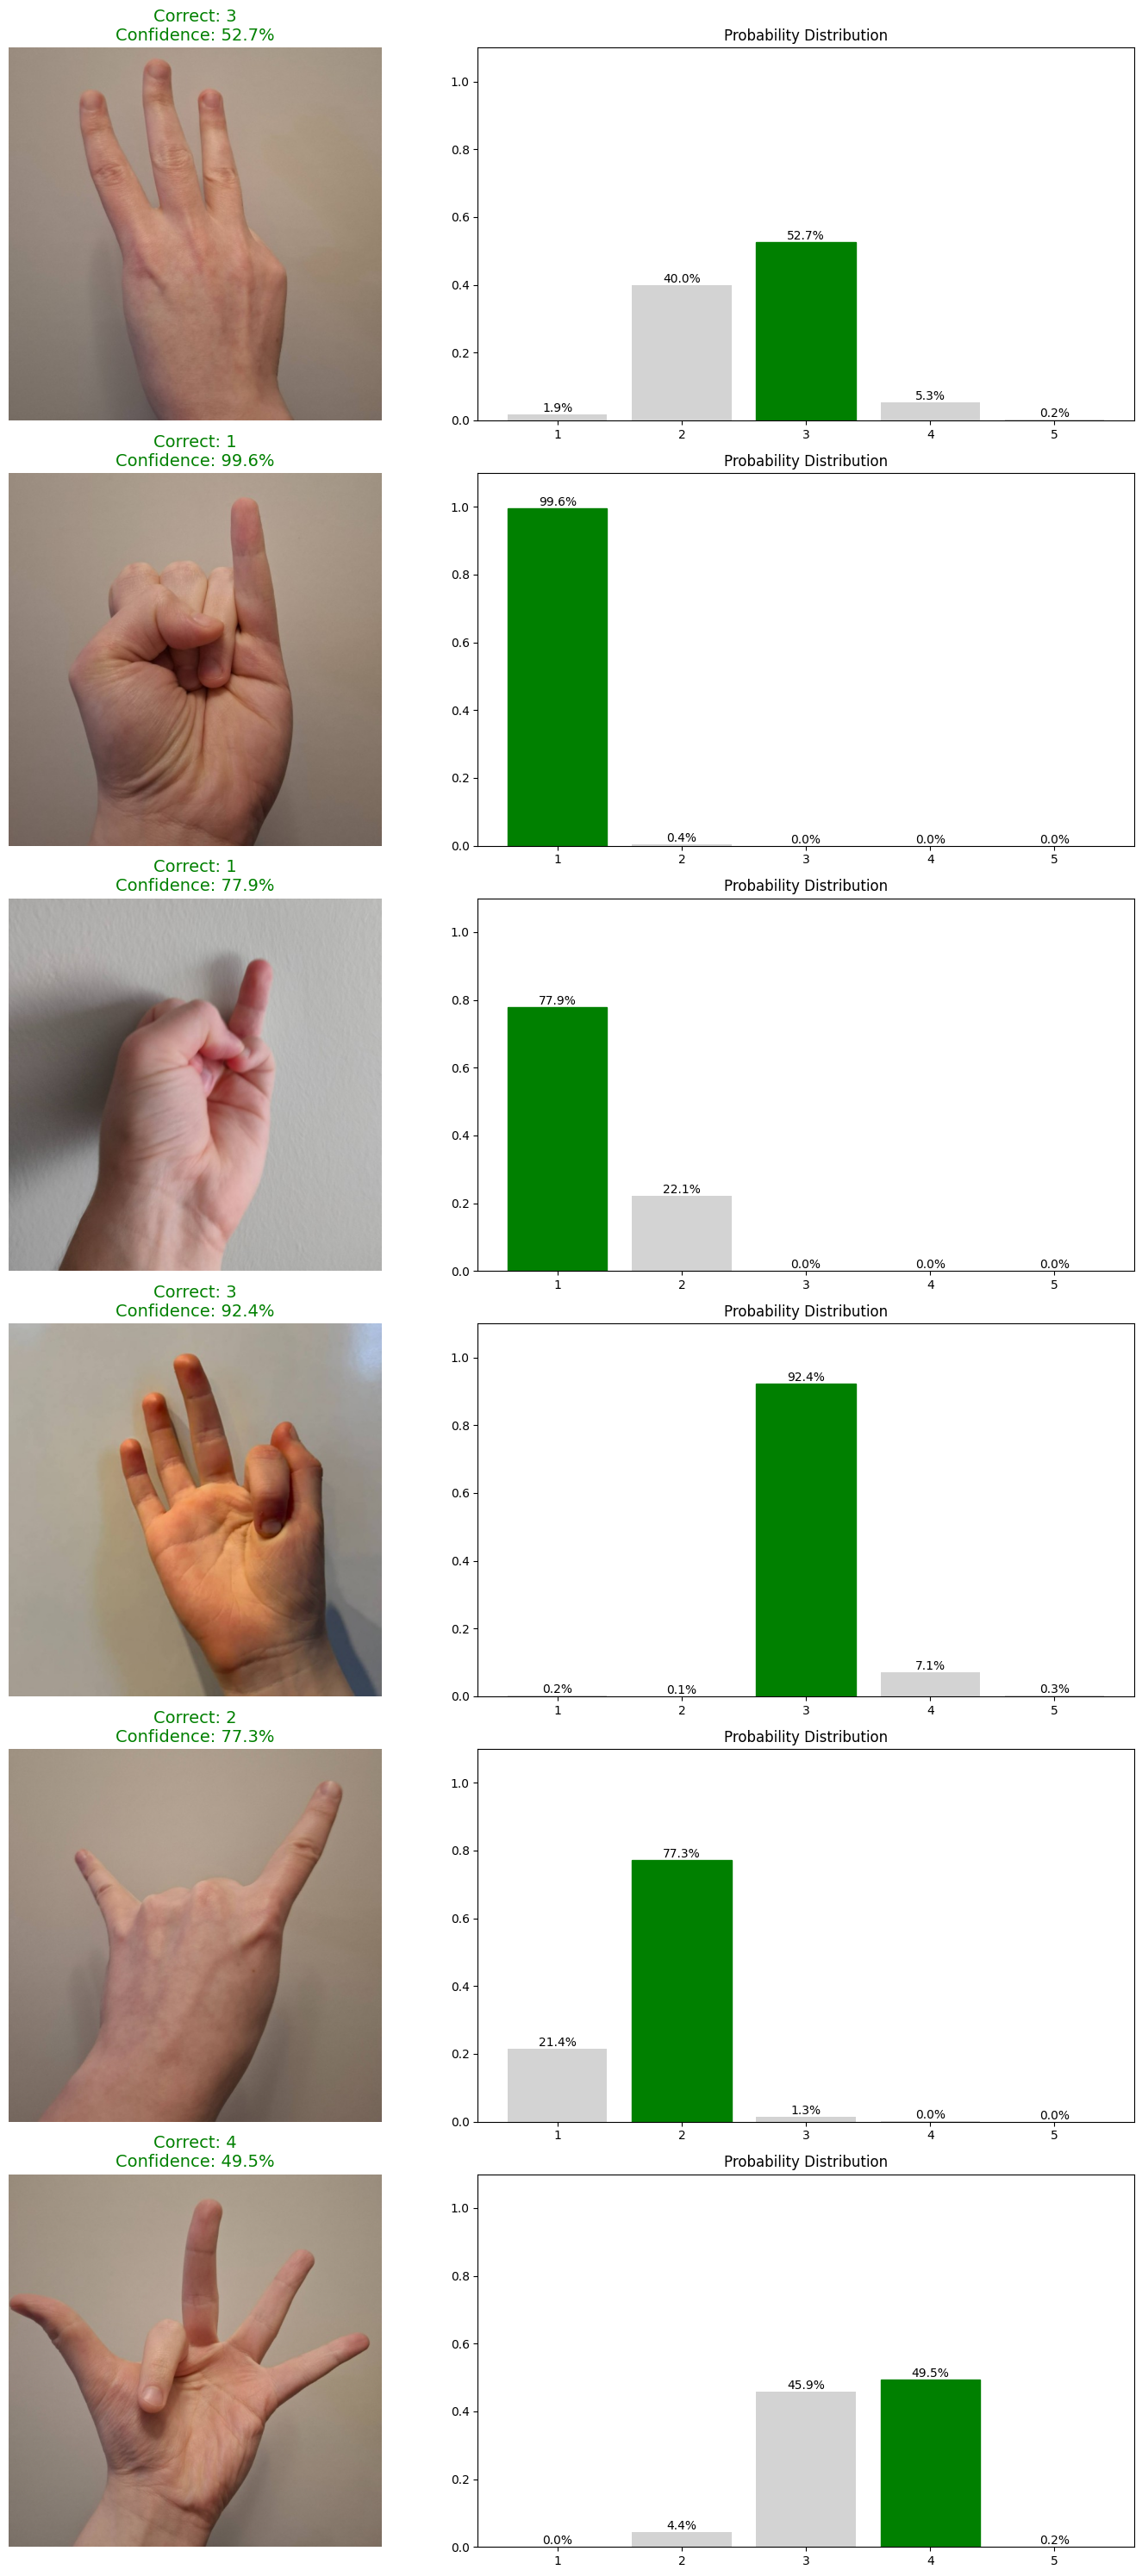

In [16]:
import numpy as np
import os
import matplotlib.pyplot as plt

corrects = np.where(y_pred_classes == y_true_classes)[0]
print(f"Total correctly classified images: {len(corrects)} out of {len(y_true_classes)}")

num_to_show = 6 
num_to_show = min(num_to_show, len(corrects))

random_corrects = np.random.choice(corrects, size=num_to_show, replace=False)

fig, axes = plt.subplots(num_to_show, 2, figsize=(15, 5 * num_to_show))

for i in range(num_to_show):
    idx = random_corrects[i]
    
    img_path = os.path.join(test_generator.directory, test_generator.filenames[idx])
    img = plt.imread(img_path)
    
    axes[i, 0].imshow(img)
    label = class_names[y_true_classes[idx]]
    confidence = y_pred[idx][y_true_classes[idx]] * 100
    
    axes[i, 0].set_title(f"Correct: {label}\nConfidence: {confidence:.1f}%", color='green', fontsize=14)
    axes[i, 0].axis('off')
    
    probabilities = y_pred[idx]
    bars = axes[i, 1].bar(class_names, probabilities, color='lightgray')
    
    correct_idx = y_true_classes[idx]
    bars[correct_idx].set_color('green')
    
    for bar in bars:
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height*100:.1f}%', ha='center', va='bottom')

    axes[i, 1].set_ylim(0, 1.1)
    axes[i, 1].set_title("Probability Distribution", fontsize=12)

plt.tight_layout()
plt.show()